In [1]:

import os
import scipy.io
import h5py
import numpy as np
import sys
from scipy import signal as sig
from scipy import stats as stats
import math
import pandas as pd
import csv
import matplotlib.pyplot as plt
from scipy import signal
import seaborn as sns
import logging

%matplotlib widget

scripts_path = '/home/apollo/Documents/github_projects/ripple_sync/scripts/hc_18_scripts/'
data_path = "/media/apollo/projects/hc-18/data/"

os.chdir(scripts_path)

import hc18_BaseFunctions as hc18_bf
import ripple_detection as ripple
import normalizing_functions as norm
import helper_functions as helper
import bootstrapped_estimation as bootstrap


sessions = ['Train-242-20140124','Train-261-20140617','Train-272-20141215','Train-292-20150501','Train-314-20160118']
animals = ['242','261','272','292','314']


In [2]:

# set the font globally
plt.rcParams.update({'font.family':'sans-serif'})
# set the font name for a font family
plt.rcParams.update({'font.sans-serif':'Arial'})
# when saving svg, keep text as text
plt.rcParams['svg.fonttype'] = 'none' 


In [3]:
import pandas as pd

path = "/home/apollo/Documents/github_projects/ripple_sync/results/"
os.chdir(path)
df_phase = pd.read_csv('Figure_Ripple_PhasePhaseCoupling_WholeSignal_hc18.csv')
df_phase


,rat,session,side,shank_1,shank_2,phase_phase_coupling,phase_phase_direction
0,242,Train-242-20140124,ipsi,0,1,0.372677,-0.294977
1,242,Train-242-20140124,ipsi,0,2,0.322364,-0.058451
2,242,Train-242-20140124,ipsi,0,3,0.350113,-0.111991
3,242,Train-242-20140124,ipsi,0,4,0.289865,-0.048621
4,242,Train-242-20140124,ipsi,0,5,0.347345,-0.107547
...,...,...,...,...,...,...,...
238,314,Train-314-20160118,ipsi,11,13,0.215157,0.570859
239,314,Train-314-20160118,ipsi,11,15,0.169741,0.364551
240,314,Train-314-20160118,ipsi,12,13,0.490396,0.135234
241,314,Train-314-20160118,ipsi,12,15,0.334293,0.228876


In [ ]:
sides = ['ipsi','contra']
mean_phase_phase_coupling = []
for session in sessions:
    state_aux = []
    df_session = df_phase['session'] == session
    for side in sides:
        
        df_side = df_phase['side'] == side
        state_aux.append(np.nanmean(df_phase['phase_phase_coupling'][df_session*df_side].values))
    mean_phase_phase_coupling.append(state_aux)
mean_phase_phase_coupling = np.array(mean_phase_phase_coupling).T
mean_phase_phase_coupling


/tmp/ipykernel_6969/4232412771.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


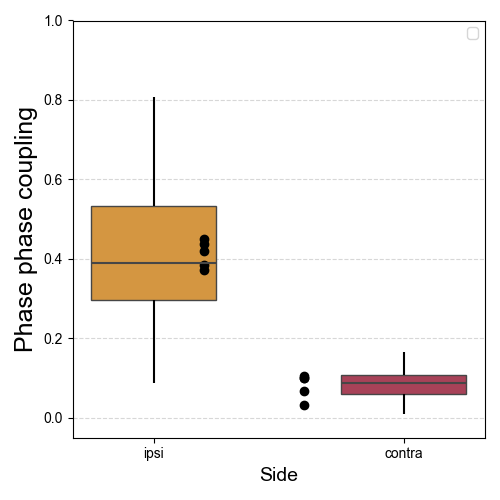

ClipPath elements deleted.
File saved.


In [22]:

plt.close('all')
plt.figure(figsize=(5,5))

my_pal ={"ipsi": "#ec9a29","contra":"#b9314f"}

# sns.stripplot(data=df, x="side", y="phase_phase_coupling", hue='side',
#               order=["ipsi", "contra"], palette=my_pal,size=6,alpha=1)

box = sns.boxplot(data=df_phase, x="side", y="phase_phase_coupling", hue='side',
            order=['ipsi','contra'], showfliers=True, showcaps=False,palette=my_pal,
            whiskerprops=dict(linestyle='-', linewidth=1.5, color='black'),
            medianprops=dict(linestyle='-', linewidth=1.5),
            width=0.5)  # Using the custom color palette

# ax=sns.violinplot(data=df,x="side", y="phase_phase_coupling", hue='side',
#                 order=["ipsi", "contra"], palette=my_pal,fill=True,inner = None,\
#                 split=True, density_norm='width',saturation=1,bw_adjust=0.5,native_scale=True)
# plt.setp(ax.collections, alpha=.3)
plt.plot([0.2,0.6],mean_phase_phase_coupling,'ko')

plt.ylabel('Phase phase coupling',fontsize=18)
plt.xlabel('Side',fontsize=14)
plt.grid(linestyle='--',alpha=0.5,axis='y')
# plt.legend([], [], frameon=False)
plt.ylim([-0.05,1])
plt.legend()
# we need to set it manually so we will be able to edit them ticks in inkscape as a path (otherwise, we need to set it as a "object to path")
# plt.xticks([0,1],labels=['Left','Right'])
plt.tight_layout()

os.chdir(scripts_path + '/figures/')
fig_name = 'Figure_Ripple_PhasePhaseCoupling_WholeSignal.svg'
plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()
helper.delete_clip_path(fig_name)



In [5]:
import statsmodels.api as sm

# Define the formula for the mixed-effects model
formula = "phase_phase_coupling ~ C(side, Treatment(reference='ipsi'))"
re_formula = "1"
vc_formula = {"session": "0 + session"}
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, vc_formula=vc_formula, data=df_phase,groups='rat')
result = model.fit()

# Print summary of the model
print(result.summary())


                          Mixed Linear Model Regression Results
Model:                    MixedLM         Dependent Variable:         phase_phase_coupling
No. Observations:         243             Method:                     REML                
No. Groups:               5               Scale:                      0.0133              
Min. group size:          28              Log-Likelihood:             171.7858            
Max. group size:          66              Converged:                  Yes                 
Mean group size:          48.6                                                            
------------------------------------------------------------------------------------------
                                               Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------
Intercept                                       0.413    0.015  26.822 0.000  0.382  0.443
C(side, Treatment(referenc

/home/apollo/.pyenv/versions/3.13.5/envs/ripple_sync/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [22]:
result.pvalues

Intercept                                         1.784003e-158
C(side, Treatment(reference='ipsi'))[T.contra]    4.476788e-110
rat Var                                                     NaN
session Var                                                 NaN
dtype: float64

In [30]:
np.nansum(df_phase['side'] == 'ipsi')

np.int64(122)

In [31]:
np.nansum(df_phase['side'] == 'contra')

np.int64(121)

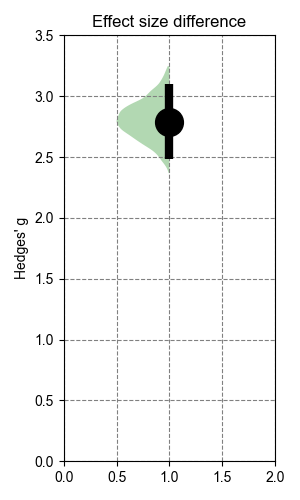

In [27]:
import bootstrapped_estimation as bootstrap
phase_phase_ipsi = []
phase_phase_contra = []
for animal in animals:
    df_slice = df_phase[df_phase['rat'] == int(animal)]
    phase_phase_ipsi.append(df_slice[df_slice['side'] == 'ipsi']['phase_phase_coupling'].values)
    phase_phase_contra.append(df_slice[df_slice['side'] == 'contra']['phase_phase_coupling'].values)
phase_phase_ipsi = np.concatenate(phase_phase_ipsi)
phase_phase_contra = np.concatenate(phase_phase_contra)    

observed_g = bootstrap.hedges_g(phase_phase_ipsi,phase_phase_contra, paired=False)
bootstrapped_g, ci_bounds = bootstrap.bootstrap_hedges_g(phase_phase_ipsi,phase_phase_contra, n_bootstraps=5000, ci=95, paired=False)
observed_g, shuffled_g, p_value = bootstrap.pvalue_hedges_g_permutation(phase_phase_ipsi,phase_phase_contra, n_permutations=5000, ci=95, paired=False)

# Compute Q1 (25th percentile) and Q3 (75th percentile)
Q1 = np.percentile(bootstrapped_g, 25)
Q3 = np.percentile(bootstrapped_g, 75)

# Compute interquartile range (IQR)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR  # Anything below this is an outlier
upper_bound = Q3 + 1.5 * IQR  # Anything above this is an outlier

lower_bound = np.nanmin([Q1 - 1.5 * IQR,np.percentile(bootstrapped_g, 2.5)])
upper_bound = np.nanmax([Q3 + 1.5 * IQR,np.percentile(bootstrapped_g, 97.5)])

# Filter out outliers
filtered_g_values = [g for g in bootstrapped_g if lower_bound <= g <= upper_bound]


plt.figure(figsize=(3,5))
violin_parts = plt.violinplot(filtered_g_values,showmeans=False,showextrema=False,side='low',positions=[1],widths=1)
for pc in violin_parts['bodies']:
    pc.set_facecolor('green')
# plt.boxplot(filtered_g_values,positions=[2])
   
plt.plot([1,1],ci_bounds,color='black',lw=6,ls='--')
plt.plot(1,observed_g,color='black',ls='',marker='o',markersize=20)
plt.plot()
plt.ylabel("Hedges' g")
plt.grid(ls='--',color='gray')
plt.xlim([0,2])
plt.ylim([0,3.5])
# plt.ylim(bottom=0)

plt.title('Effect size difference')
plt.tight_layout()

os.chdir(scripts_path + '/figures/')
fig_name = 'Figure_Ripple_PhasePhaseCoupling_WholeSignal_EffectSize.svg'
# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()
# helper.delete_clip_path(fig_name)



In [29]:
print(observed_g)
print(ci_bounds)
print(p_value)


2.788675569974134
(np.float64(2.484573796229663), np.float64(3.162491793985271))
0.0001999600079984003


In [ ]:
df

In [9]:

import pandas as pd

path = "/home/apollo/Documents/github_projects/ripple_sync/results/"
os.chdir(path)
df_amp = pd.read_csv('Figure_Ripple_AmpAmpCoupling_WholeSignal_hc18.csv')
df_amp

,rat,session,side,shank_1,shank_2,slope,intercept,r_value,p_value,std_err
0,242,Train-242-20140124,ipsi,0,1,2.471096,-237.826921,0.811659,0.0,0.003162
1,242,Train-242-20140124,ipsi,0,2,2.216317,-185.252524,0.761562,0.0,0.003353
2,242,Train-242-20140124,ipsi,0,3,2.196171,-290.725854,0.795103,0.0,0.002978
3,242,Train-242-20140124,ipsi,0,4,2.934438,-443.088871,0.765209,0.0,0.004389
4,242,Train-242-20140124,ipsi,0,5,1.580146,-131.937042,0.803931,0.0,0.002078
...,...,...,...,...,...,...,...,...,...,...
238,314,Train-314-20160118,ipsi,11,13,1.073057,10.858649,0.890987,0.0,0.000917
239,314,Train-314-20160118,ipsi,11,15,0.493401,28.712659,0.816738,0.0,0.000584
240,314,Train-314-20160118,ipsi,12,13,1.226878,2.970587,0.945235,0.0,0.000710
241,314,Train-314-20160118,ipsi,12,15,0.557972,25.547483,0.857010,0.0,0.000563


In [15]:
sides = ['ipsi','contra']
mean_r_value = []
for session in sessions:
    state_aux = []
    df_session = df_amp['session'] == session
    for side in sides:
        
        df_side = df_amp['side'] == side
        state_aux.append(np.nanmean(df_amp['r_value'][df_session*df_side].values))
    mean_r_value.append(state_aux)
mean_r_value = np.array(mean_r_value).T
mean_r_value




array([[0.89242265, 0.8906654 , 0.8040889 , 0.88212092, 0.88180429],
       [0.74376761, 0.80689702, 0.66315986, 0.84057134, 0.83000216]])

/tmp/ipykernel_6969/1688969966.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


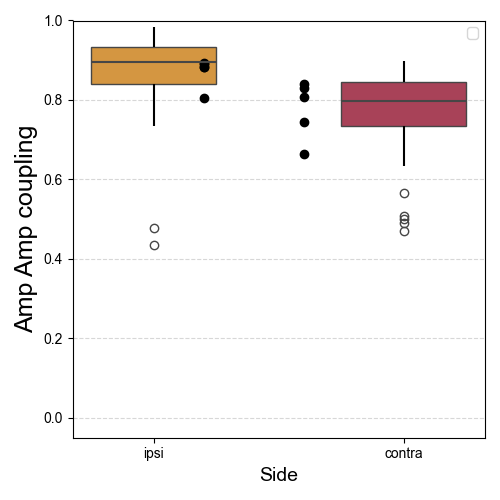

ClipPath elements deleted.
File saved.


In [20]:

plt.close('all')
plt.figure(figsize=(5,5))

my_pal ={"ipsi": "#ec9a29","contra":"#b9314f"}

# sns.stripplot(data=df, x="side", y="r_value", hue='side',
#               order=["ipsi", "contra"], palette=my_pal,size=6,alpha=1)

box = sns.boxplot(data=df_amp, x="side", y="r_value", hue='side',
            order=['ipsi','contra'], showfliers=True, showcaps=False,palette=my_pal,
            whiskerprops=dict(linestyle='-', linewidth=1.5, color='black'),
            medianprops=dict(linestyle='-', linewidth=1.5),
            width=0.5)  # Using the custom color palette

# ax=sns.violinplot(data=df,x="side", y="r_value", hue='side',
#                 order=["ipsi", "contra"], palette=my_pal,fill=True,inner = None,\
#                 split=True, density_norm='width',saturation=1,bw_adjust=0.5,native_scale=True)
# plt.setp(ax.collections, alpha=.3)

plt.plot([0.2,0.6],mean_r_value,'ko')
plt.ylabel('Amp Amp coupling',fontsize=18)
plt.xlabel('Side',fontsize=14)
plt.grid(linestyle='--',alpha=0.5,axis='y')
# plt.legend([], [], frameon=False)
plt.ylim([-0.05,1])
plt.legend()
# we need to set it manually so we will be able to edit them ticks in inkscape as a path (otherwise, we need to set it as a "object to path")
# plt.xticks([0,1],labels=['Left','Right'])
plt.tight_layout()

os.chdir(scripts_path + '/figures/')
fig_name = 'Figure_Ripple_AmpAmpCoupling_WholeSignal.svg'

plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()
helper.delete_clip_path(fig_name)




In [11]:
import statsmodels.api as sm

# Define the formula for the mixed-effects model
formula = "r_value ~ C(side, Treatment(reference='ipsi'))"
re_formula = "1"
vc_formula = {"session": "0 + session"}
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, vc_formula=vc_formula, data=df_amp,groups='rat')
result = model.fit()

# Print summary of the model
print(result.summary())


                           Mixed Linear Model Regression Results
Model:                          MixedLM             Dependent Variable:             r_value 
No. Observations:               243                 Method:                         REML    
No. Groups:                     5                   Scale:                          0.0054  
Min. group size:                28                  Log-Likelihood:                 277.1637
Max. group size:                66                  Converged:                      Yes     
Mean group size:                48.6                                                        
--------------------------------------------------------------------------------------------
                                               Coef.   Std.Err.     z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------------------
Intercept                                       0.870      0.024  36.463 0.000  0.823  0.917
C(sid

/home/apollo/.pyenv/versions/3.13.5/envs/ripple_sync/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [19]:
result.pvalues

Intercept                                         4.265867e-291
C(side, Treatment(reference='ipsi'))[T.contra]     9.193960e-24
rat Var                                            9.999999e-01
session Var                                        9.999999e-01
dtype: float64

In [17]:
np.nansum(df_amp['side'] == 'ipsi')
np.nansum(df_amp['side'] == 'contra')


np.int64(121)

array([[0.89242265, 0.8906654 , 0.8040889 , 0.88212092, 0.88180429],
       [0.74376761, 0.80689702, 0.66315986, 0.84057134, 0.83000216]])

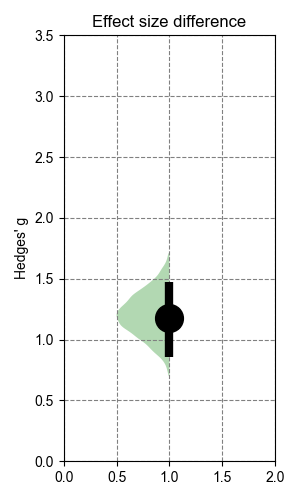

In [32]:
import bootstrapped_estimation as bootstrap

r_value_ipsi = []
r_value_contra = []
for animal in animals:
    df_slice = df_amp[df_amp['rat'] == int(animal)]
    r_value_ipsi.append(df_slice[df_slice['side'] == 'ipsi']['r_value'].values)
    r_value_contra.append(df_slice[df_slice['side'] == 'contra']['r_value'].values)
r_value_ipsi = np.concatenate(r_value_ipsi)
r_value_contra = np.concatenate(r_value_contra)



observed_g = bootstrap.hedges_g(r_value_ipsi,r_value_contra, paired=False)

bootstrapped_g, ci_bounds = bootstrap.bootstrap_hedges_g(r_value_ipsi,r_value_contra, n_bootstraps=5000, ci=95, paired=False)

observed_g, shuffled_g, p_value = bootstrap.pvalue_hedges_g_permutation(r_value_ipsi,r_value_contra, n_permutations=5000, ci=95, paired=False)


# Compute Q1 (25th percentile) and Q3 (75th percentile)
Q1 = np.percentile(bootstrapped_g, 25)
Q3 = np.percentile(bootstrapped_g, 75)

# Compute interquartile range (IQR)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR  # Anything below this is an outlier
upper_bound = Q3 + 1.5 * IQR  # Anything above this is an outlier

lower_bound = np.nanmin([Q1 - 1.5 * IQR,np.percentile(bootstrapped_g, 2.5)])
upper_bound = np.nanmax([Q3 + 1.5 * IQR,np.percentile(bootstrapped_g, 97.5)])

# Filter out outliers
filtered_g_values = [g for g in bootstrapped_g if lower_bound <= g <= upper_bound]

plt.figure(figsize=(3,5))
violin_parts = plt.violinplot(filtered_g_values,showmeans=False,showextrema=False,side='low',positions=[1],widths=1)
for pc in violin_parts['bodies']:
    pc.set_facecolor('green')
# plt.boxplot(filtered_g_values,positions=[2])
   
plt.plot([1,1],ci_bounds,color='black',lw=6,ls='--')
plt.plot(1,observed_g,color='black',ls='',marker='o',markersize=20)
plt.plot()
plt.ylabel("Hedges' g")
plt.grid(ls='--',color='gray')
plt.xlim([0,2])
plt.ylim([0,3.5])
plt.ylim(bottom=0)
plt.title('Effect size difference')
plt.tight_layout()

os.chdir(scripts_path + '/figures/')
fig_name = 'Figure_Ripple_AmpAmpCoupling_WholeSignal_EffectSize.svg'

# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()
# helper.delete_clip_path(fig_name)





In [33]:
print(observed_g)
print(ci_bounds)
print(p_value)


1.1811999935330808
(np.float64(0.8604170811943783), np.float64(1.5659921506754788))
0.0001999600079984003


In [34]:
ci = 95
observed_g_amp = bootstrap.hedges_g(r_value_ipsi,r_value_contra, paired=False)
bootstrapped_g_amp, ci_bounds_amp = bootstrap.bootstrap_hedges_g(r_value_ipsi,r_value_contra, n_bootstraps=5000, ci=95, paired=False)

observed_g_phase = bootstrap.hedges_g(phase_phase_ipsi,phase_phase_contra, paired=False)
bootstrapped_g_phase, ci_bounds_phase = bootstrap.bootstrap_hedges_g(phase_phase_ipsi,phase_phase_contra, n_bootstraps=5000, ci=95, paired=False)

boot_dd = bootstrapped_g_phase - bootstrapped_g_amp

lower = np.percentile(boot_dd, (100-ci)/2)
upper = np.percentile(boot_dd, 100-(100-ci)/2)
ci_bounds = (lower, upper)

obs = observed_g_phase - observed_g_amp 


array([2.4105275 , 2.81985656, 2.74436646, ..., 2.53690038, 2.82841108,
       2.94529636], shape=(5000,))

In [38]:
observed_g, shuffled_g, p_value = bootstrap.pvalue_hedges_g_permutation(bootstrapped_g_phase,bootstrapped_g_amp, n_permutations=5000, ci=95, paired=False)


In [41]:
stats.ttest_ind(bootstrapped_g_phase,bootstrapped_g_amp)

TtestResult(statistic=np.float64(460.1984019124169), pvalue=np.float64(0.0), df=np.float64(9998.0))

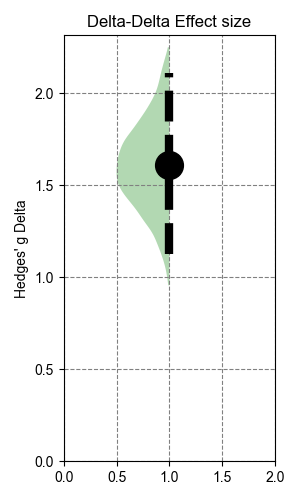

In [35]:

# Compute Q1 (25th percentile) and Q3 (75th percentile)
Q1 = np.percentile(boot_dd, 25)
Q3 = np.percentile(boot_dd, 75)

# Compute interquartile range (IQR)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR  # Anything below this is an outlier
upper_bound = Q3 + 1.5 * IQR  # Anything above this is an outlier

lower_bound = np.nanmin([Q1 - 1.5 * IQR,np.percentile(boot_dd, 2.5)])
upper_bound = np.nanmax([Q3 + 1.5 * IQR,np.percentile(boot_dd, 97.5)])

# Filter out outliers
filtered_g_values = [g for g in boot_dd if lower_bound <= g <= upper_bound]

plt.figure(figsize=(3,5))
violin_parts = plt.violinplot(filtered_g_values,showmeans=False,showextrema=False,side='low',positions=[1],widths=1)
for pc in violin_parts['bodies']:
    pc.set_facecolor('green')

plt.plot([1,1],ci_bounds,color='black',lw=6,ls='--')
plt.plot(1,obs,color='black',ls='',marker='o',markersize=20)
plt.plot()
plt.ylabel("Hedges' g Delta")
plt.grid(ls='--',color='gray')
plt.xlim([0,2])
# plt.ylim([0,3.5])
plt.ylim(bottom=0)
plt.title('Delta-Delta Effect size')
plt.tight_layout()

os.chdir(scripts_path + '/figures/')
fig_name = 'Figure_Delta_Delta_EffectSize.svg'

# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()
# helper.delete_clip_path(fig_name)



In [36]:
print(obs)
print(ci_bounds)
print(p_value)


1.6074755764410533
(np.float64(1.1284497477221824), np.float64(2.10861714388368))
0.0001999600079984003
